In [3]:
# ==============================================================================
# Counterfactual Explanations Pipeline (Paper 2)
# Stable + Optimized Version + Feature Set Selector
# ==============================================================================

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import dice_ml

from pyprojroot import here
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# FEATURE SET MODE (เลือกโหมดที่ต้องการ)
# ------------------------------------------------------------------------------
# "core"     = ใช้เฉพาะ 6 ทักษะหลัก (เหมาะสำหรับ Paper 2 main figure)
# "full"     = ใช้ฟีเจอร์ทั้งหมด (รวม risk scores)
# "custom"   = คุณกำหนดเองใน FEATURE_SET_CUSTOM
# ------------------------------------------------------------------------------
FEATURE_SET_MODE = "core"   # ← เปลี่ยนตรงนี้ได้เลย

FEATURE_SET_CUSTOM = [
    # ตัวอย่าง (แก้ได้ตามต้องการ)
    'Avg_ProdManage', 'Avg_InputManage', 'Avg_Tech'
]

# ------------------------------------------------------------------------------
# STEP 0: เตรียมโฟลเดอร์
# ------------------------------------------------------------------------------
OUT_DIR = 'figures_paper2'
os.makedirs(OUT_DIR, exist_ok=True)

base_path = here()
file_path = os.path.join(base_path, "datas", "SFProgramDataPanal_with_clusters.csv")

df = pd.read_csv(file_path)

# ------------------------------------------------------------------------------
# STEP 1: Data Preparation
# ------------------------------------------------------------------------------
print("--- STEP 1: Loading Data & Stable Clusters ---")

df = df.replace('.', np.nan)
df_y0 = df[df['Year'] == 0].copy()

CLUSTER_FEATS = [
    'age', 'edu', 'agri_long', 'irriga', 'loan',
    'Avg_ProdManage', 'Avg_InputManage', 'Avg_Tech',
    'Avg_Ana&Plan', 'Avg_Mkting', 'Avg_Network',
    'Ave_ProdRisk', 'Ave_InputRisk', 'Ave_MktRisk', 'Ave_FinRisk'
]

df_cf = df_y0[['id', 'Cluster'] + CLUSTER_FEATS].apply(
    pd.to_numeric, errors='coerce'
).dropna().copy()

X_df = df_cf[CLUSTER_FEATS].copy()
y_df = df_cf['Cluster'].copy()

print(f"Data Loaded: {len(X_df)} records. Clusters Distribution:\n{y_df.value_counts().to_string()}")

--- STEP 1: Loading Data & Stable Clusters ---
Data Loaded: 417 records. Clusters Distribution:
Cluster
0    153
2    145
1    119


In [4]:
# ------------------------------------------------------------------------------
# STEP 2: เลือกชุดฟีเจอร์สำหรับ Action Plan ตามโหมดที่เลือก
# ------------------------------------------------------------------------------
if FEATURE_SET_MODE == "core":
    ACTION_FEATS = [
        'Avg_ProdManage', 'Avg_InputManage', 'Avg_Tech',
        'Avg_Ana&Plan', 'Avg_Mkting', 'Avg_Network'
    ]
elif FEATURE_SET_MODE == "full":
    ACTION_FEATS = [
        'Avg_ProdManage', 'Avg_InputManage', 'Avg_Tech',
        'Avg_Ana&Plan', 'Avg_Mkting', 'Avg_Network',
        'Ave_ProdRisk', 'Ave_InputRisk', 'Ave_MktRisk', 'Ave_FinRisk'
    ]
elif FEATURE_SET_MODE == "custom":
    ACTION_FEATS = FEATURE_SET_CUSTOM
else:
    raise ValueError("Invalid FEATURE_SET_MODE")

print(f"\n✓ Using Feature Set Mode: {FEATURE_SET_MODE}")
print(f"✓ Actionable Features: {ACTION_FEATS}")

# ------------------------------------------------------------------------------
# COURSE MAPPING (สร้างตาม ACTION_FEATS)
# ------------------------------------------------------------------------------
COURSE_MAPPING = {
    'Avg_ProdManage': 'Production Management',
    'Avg_InputManage': 'Input Management',
    'Avg_Tech': 'Technology Adoption',
    'Avg_Ana&Plan': 'Analysis & Planning',
    'Avg_Mkting': 'Marketing',
    'Avg_Network': 'Networking',
    'Ave_ProdRisk': 'Production Risk Management',
    'Ave_InputRisk': 'Input Risk Management',
    'Ave_MktRisk': 'Market Risk Management',
    'Ave_FinRisk': 'Financial Risk Management'
}

# จำกัด mapping เฉพาะฟีเจอร์ที่เลือก
COURSE_MAPPING = {k: v for k, v in COURSE_MAPPING.items() if k in ACTION_FEATS}


✓ Using Feature Set Mode: core
✓ Actionable Features: ['Avg_ProdManage', 'Avg_InputManage', 'Avg_Tech', 'Avg_Ana&Plan', 'Avg_Mkting', 'Avg_Network']


In [5]:
# ------------------------------------------------------------------------------
# STEP 3: Train RF
# ------------------------------------------------------------------------------
print("\n--- STEP 3: Training Black-Box Classifier ---")

RF_PARAMS = dict(
    n_estimators=500,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_final = RandomForestClassifier(**RF_PARAMS)
rf_final.fit(X_df, y_df)

train_acc = accuracy_score(y_df, rf_final.predict(X_df))
print(f"✓ Base Classifier Trained (Accuracy: {train_acc:.4f})")

# ------------------------------------------------------------------------------
# STEP 4: Setup DiCE
# ------------------------------------------------------------------------------
immutable_feats = ['age', 'edu', 'agri_long']
features_to_vary = [f for f in CLUSTER_FEATS if f not in immutable_feats]

d_data = dice_ml.Data(
    dataframe=pd.concat([X_df, y_df], axis=1),
    continuous_features=CLUSTER_FEATS,
    outcome_name='Cluster'
)
d_model = dice_ml.Model(model=rf_final, backend="sklearn", model_type="classifier")
exp_dice = dice_ml.Dice(d_data, d_model, method="genetic")

# ------------------------------------------------------------------------------
# Precompute permitted_range per-sample
# ------------------------------------------------------------------------------
def precompute_ranges_for_samples(samples, X_full):
    ranges_map = {}
    for idx, row in samples.iterrows():
        farmer_profile = pd.DataFrame([row])
        ranges = {}
        for feat in features_to_vary:
            val = float(farmer_profile[feat].values[0])
            if 'Avg_' in feat:
                ranges[feat] = [val, val + 0.01] if val >= 5.0 else [val, 5.0]
            else:
                ranges[feat] = [X_full[feat].min(), X_full[feat].max()]
        ranges_map[idx] = ranges
    return ranges_map


--- STEP 3: Training Black-Box Classifier ---
✓ Base Classifier Trained (Accuracy: 0.9640)


In [6]:
# ------------------------------------------------------------------------------
# STEP 5: Process 1 Farmer
# ------------------------------------------------------------------------------
def process_single_farmer(index, row, source_cluster, target_cluster, ranges_map):
    farmer_profile = pd.DataFrame([row])
    ranges = ranges_map[index]

    result_metric = {'valid': 0, 'sparsity': np.nan, 'l1': np.nan}
    local_action_plans = []

    try:
        cf_res = exp_dice.generate_counterfactuals(
            farmer_profile,
            total_CFs=5,
            desired_class=target_cluster,
            features_to_vary=features_to_vary,
            permitted_range=ranges,
            posthoc_sparsity_param=0.1
        )

        if cf_res and len(cf_res.cf_examples_list) > 0:
            orig_df = cf_res.cf_examples_list[0].test_instance_df
            cfs_df = cf_res.cf_examples_list[0].final_cfs_df

            best_sparsity, best_l1, best_cf_row = 999, 999.0, None

            for _, cf_row in cfs_df.iterrows():
                is_valid = rf_final.predict(pd.DataFrame([cf_row])[CLUSTER_FEATS])[0] == target_cluster
                if not is_valid:
                    continue

                changed_feats = 0
                l1_dist = 0.0

                for feat in features_to_vary:
                    diff = float(cf_row[feat]) - float(orig_df[feat].values[0])
                    if diff > 0.01:
                        changed_feats += 1
                        l1_dist += diff

                if changed_feats < best_sparsity or (changed_feats == best_sparsity and l1_dist < best_l1):
                    best_sparsity = changed_feats
                    best_l1 = l1_dist
                    best_cf_row = cf_row

            if best_cf_row is not None:
                result_metric = {'valid': 1, 'sparsity': best_sparsity, 'l1': best_l1}

                for feat in ACTION_FEATS:
                    diff = float(best_cf_row[feat]) - float(orig_df[feat].values[0])
                    if diff >= 0.1:
                        local_action_plans.append({
                            'Farmer_ID': index,
                            'Path': f'C{source_cluster} -> C{target_cluster}',
                            'Course': COURSE_MAPPING[feat],
                            'Increment': diff
                        })

    except Exception as e:
        print(f"[Worker Error] Farmer ID {index} error: {e}")

    return result_metric, local_action_plans

In [7]:
# ------------------------------------------------------------------------------
# STEP 6: Batch Evaluation
# ------------------------------------------------------------------------------
def run_batch_evaluation_parallel(source_cluster, target_cluster, limit=None):
    samples = X_df[y_df == source_cluster]
    if limit:
        samples = samples.head(limit)

    print(f"Processing C{source_cluster} -> C{target_cluster} ({len(samples)} farmers)...")
    start_time = time.time()

    ranges_map = precompute_ranges_for_samples(samples, X_df)

    parallel_outputs = Parallel(n_jobs=-1)(
        delayed(process_single_farmer)(index, row, source_cluster, target_cluster, ranges_map)
        for index, row in samples.iterrows()
    )

    results, action_plans = [], []
    for metric, plans in parallel_outputs:
        results.append(metric)
        action_plans.extend(plans)

    res_df = pd.DataFrame(results)
    suc_rate = res_df['valid'].mean() * 100
    avg_sp = res_df[res_df['valid'] == 1]['sparsity'].mean()
    avg_l1 = res_df[res_df['valid'] == 1]['l1'].mean()
    exec_t = time.time() - start_time

    print(f" ✓ Success {suc_rate:.1f}% | Sparsity {avg_sp:.2f} | L1 {avg_l1:.2f} | Time {exec_t:.1f}s")

    return action_plans

Processing C0 -> C1 (153 farmers)...


100%|██████████| 1/1 [01:20<00:00, 80.51s/it]


 ✓ Success 100.0% | Sparsity 3.80 | L1 3.64 | Time 106.8s
Processing C1 -> C2 (119 farmers)...


100%|██████████| 1/1 [01:22<00:00, 82.31s/it]


 ✓ Success 100.0% | Sparsity 1.76 | L1 1.92 | Time 98.3s
Processing C0 -> C2 (153 farmers)...


100%|██████████| 1/1 [01:21<00:00, 81.34s/it]


 ✓ Success 100.0% | Sparsity 2.77 | L1 2.74 | Time 132.4s

--- STEP 8: Visualizing Results ---
✓ Visualization saved to: figures_paper2/fig_training_recommendations.png


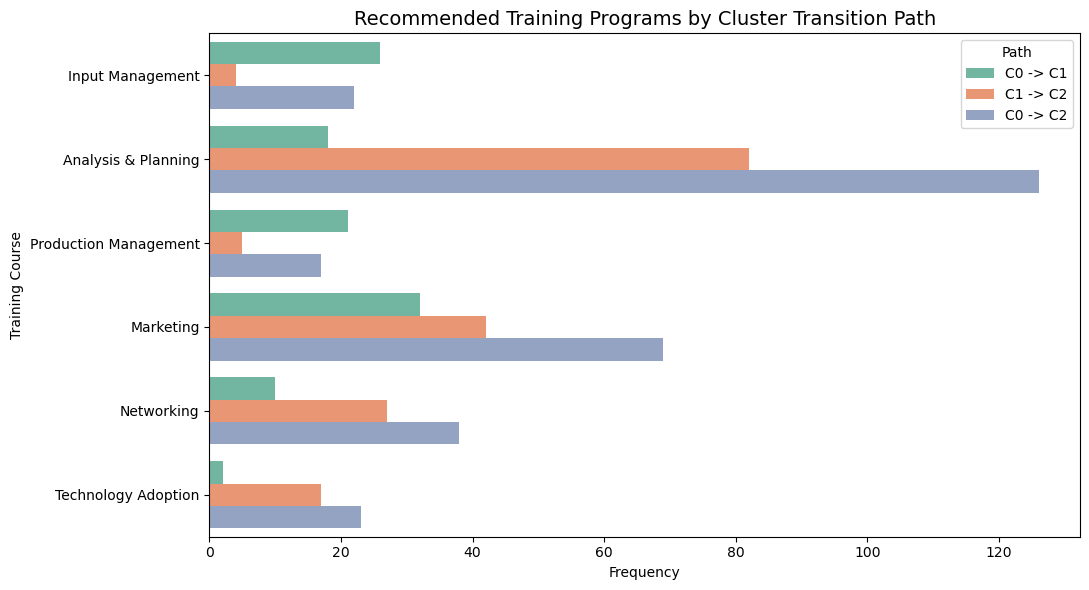

In [8]:
# ------------------------------------------------------------------------------
# STEP 7: Run All Transitions
# ------------------------------------------------------------------------------
plans_0_to_1 = run_batch_evaluation_parallel(0, 1, limit=None)
plans_1_to_2 = run_batch_evaluation_parallel(1, 2, limit=None)
plans_0_to_2 = run_batch_evaluation_parallel(0, 2, limit=None)

# ------------------------------------------------------------------------------
# STEP 8: Visualization
# ------------------------------------------------------------------------------
print("\n--- STEP 8: Visualizing Results ---")

all_plans = pd.DataFrame(plans_0_to_1 + plans_1_to_2 + plans_0_to_2)

if not all_plans.empty:
    plt.figure(figsize=(11, 6))
    sns.countplot(data=all_plans, y='Course', hue='Path', palette='Set2')

    plt.title('Recommended Training Programs by Cluster Transition Path', fontsize=14)
    plt.xlabel('Frequency')
    plt.ylabel('Training Course')
    plt.tight_layout()

    save_path = f"{OUT_DIR}/fig_training_recommendations.png"
    plt.savefig(save_path, dpi=300)
    print(f"✓ Visualization saved to: {save_path}")
    plt.show()
else:
    print("✕ No action plans were generated.")